### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [3]:
from functions import gini_coeficient

import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [4]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [5]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [6]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se nos valores numericos apresentam valores abaixo de 0

In [7]:
colunas_numericas = [c  for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:\n")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:

Avg_Open_To_Buy


In [8]:
# substituição dos valores negativos por 0

df_credit['Avg_Open_To_Buy'] = df_credit['Avg_Open_To_Buy'].map(lambda x: 0 if x < 0 else x)


In [9]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [10]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

Adaptação dos Dados

In [11]:
# Nessa etapa será adaptada as colunas string que serão testadas nos modelos

df_base_credit = df_credit.copy()

income_category_map = {"Unknown": 0, "Less than $40K": 1, "$40K - $60K": 2,
                       "$60K - $80K": 3, "$80K - $120K": 4, "$120K +": 5}

education_map = {
       'Uneducated': 0, 'High School': 1, 'College': 2,
       'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5 
}

atrition_flag_map = {
    'Existing Customer': 1,
    'Attrited Customer': 0
}

df_base_credit['Is_Male'] = df_base_credit['Gender'].map(lambda x: x == 'M').astype("int")
df_base_credit['Is_Female'] = df_base_credit['Gender'].map(lambda x: x == 'F').astype("int")

df_base_credit['Attrition_Flag'] = df_base_credit['Attrition_Flag'].map(lambda x: atrition_flag_map[x]).astype("int")

df_base_credit['Income_Category'] = df_base_credit['Income_Category'].map(
                                                                            lambda x: income_category_map[x]
                                                                        ).astype("int")

df_base_credit['Education_Level'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: education_map[x]
                                                                        ).astype("int")

df_base_credit['Status_Divorced'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Divorced').astype("int")
df_base_credit['Status_Single'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Single').astype("int")
df_base_credit['Status_Married'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Married').astype("int")

df_base_credit['Is_Blue_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Blue').astype("int")
df_base_credit['Is_Silver_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Silver').astype("int")
df_base_credit['Is_Gold_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Gold').astype("int")
df_base_credit['Is_Platinum_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Platinum').astype("int")


Validação das colunas com alta correlação com o target

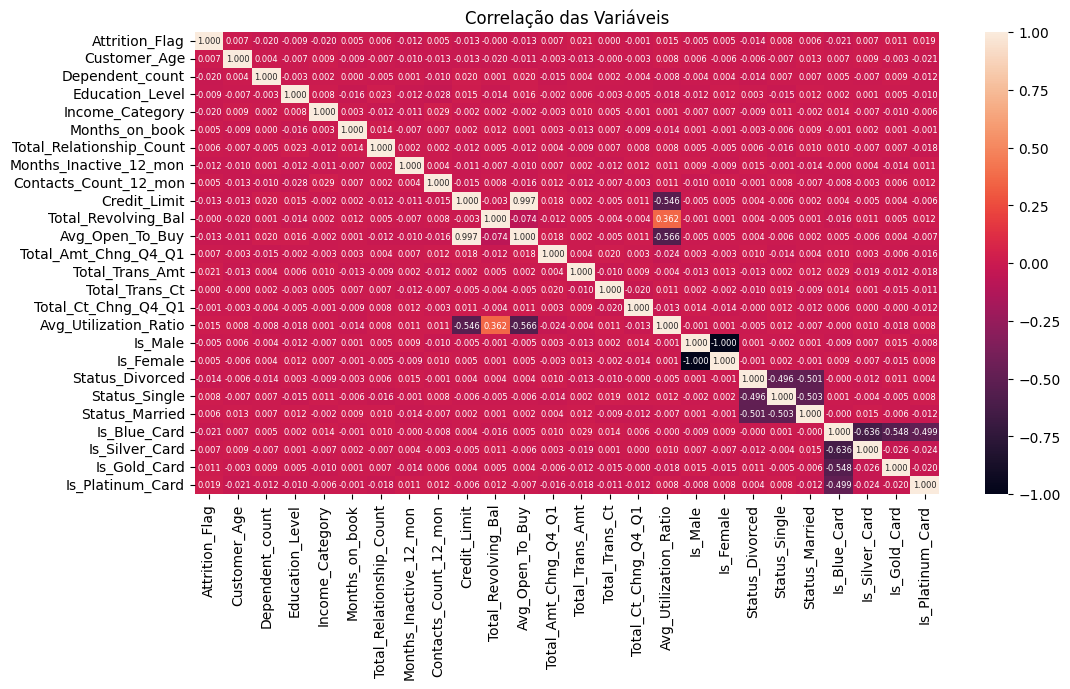

In [12]:
base_correlacao = df_base_credit.drop(columns=['Gender', 'CLIENTNUM', 
                                               'Marital_Status', 'Card_Category']).corr()

plt.figure(figsize=(12, 6))

sns.heatmap(data=base_correlacao, 
            annot=True, fmt=".3f", annot_kws={"size": 6})
plt.title("Correlação das Variáveis")
plt.show()

Conlusões

* A coluna Is_Female representa uma redundância da coluna Is_Male, portanto
  não sendo necessaria para analise do modelo de classificação

* A coluna Avg_Open_To_By é o calculo do credito limite menos
  o valor que fo utilizado, é matematicamente identico ao Credit_Limit

* A coluna CLIENTNUM será removida pois apresenta valores repetidos, 
  e então atrapalhando na classificação dos dados


In [13]:
df_base_credit = df_base_credit.drop(columns=['CLIENTNUM', 'Gender', 'Marital_Status', 
                                              'Card_Category', 'Is_Female', 'Avg_Open_To_Buy'])


Definição das variáveis de treino e teste

In [14]:
X = df_base_credit.drop(columns=['Attrition_Flag'])
y = df_base_credit['Attrition_Flag']

# Será dividido os dados dos eixos x e y em 80% de treino e 20% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Modelo de Regressão Logística

In [15]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [16]:
# Modelo Logistic Regression
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=2000)
logistic_regression.fit(X_train_scalled, Y_train)

# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]
prob_lr

array([0.53681316, 0.48965934, 0.4622928 , ..., 0.54964727, 0.49950565,
       0.5155443 ], shape=(2000,))

In [18]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_lr = gini_coeficient(Y_test, prob_lr)

print(f'Coeficiente de Gini (Logistic Regression): {gini_lr}')

Coeficiente de Gini (Logistic Regression): 0.10133247367289933


In [19]:
# Análise de quais colunas estão afetando o Modelo

pd.DataFrame({
    'Coluna': X_train.columns,
    'Coeficiente': logistic_regression.coef_[0]   
}).sort_values(by='Coeficiente', ascending=True)


,Coluna,Coeficiente
1,Dependent_count,-4.93e-02
3,Income_Category,-4.85e-02
6,Months_Inactive_12_mon,-3.60e-02
16,Status_Divorced,-3.54e-02
9,Total_Revolving_Bal,-2.72e-02
19,Is_Blue_Card,-2.44e-02
2,Education_Level,-1.41e-02
15,Is_Male,-1.28e-02
20,Is_Silver_Card,-1.22e-02
12,Total_Trans_Ct,-4.73e-03


In [20]:
y_pred = logistic_regression.predict(X_test_scalled)

# Matriz de Conversão (usado para prever as saídas reais e previstes)
print("Matriz de Confusão")
print(confusion_matrix(Y_test, y_pred), "\n")

# Exibição do relatório de Logistic Regression
print("Relatório Logistic Regression")
print(classification_report(Y_test, y_pred, target_names=['Churn', 'Permaneceu']))


Matriz de Confusão
[[179 129]
 [857 835]] 

Relatório Logistic Regression
              precision    recall  f1-score   support

       Churn       0.17      0.58      0.27       308
  Permaneceu       0.87      0.49      0.63      1692

    accuracy                           0.51      2000
   macro avg       0.52      0.54      0.45      2000
weighted avg       0.76      0.51      0.57      2000



In [21]:
scores = cross_val_score(logistic_regression, X, y, cv=5,scoring='f1')

print(f'Média: {scores.mean()}')

c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://s

Média: 0.6494050232779933


c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Random Florest

In [22]:
# Modelo Random Florest

# criação do modelo
random_florest = RandomForestClassifier(class_weight='balanced', random_state=42) 
# class_weight: Balanceamento de pesos

# treinar o modelo
random_florest.fit(X_train, Y_train)

# Predição do RandomFlorest
previsao_final = random_florest.predict(X_test)


In [23]:

# Matriz de Conversão (usado para prever as saídas reais e previstes)
print("Matriz de Confusão")
print(confusion_matrix(Y_test, previsao_final), "\n")

# Exibição do relatório de Random Florest
print("Relatório Random Florest")
print(classification_report(Y_test, previsao_final, target_names=['Churn', 'Permaneceu']))

Matriz de Confusão
[[   0  308]
 [   0 1692]] 

Relatório Random Florest
              precision    recall  f1-score   support

       Churn       0.00      0.00      0.00       308
  Permaneceu       0.85      1.00      0.92      1692

    accuracy                           0.85      2000
   macro avg       0.42      0.50      0.46      2000
weighted avg       0.72      0.85      0.78      2000



c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [24]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

# Obtenção de Probabilidades (importante para o Gini), 
prob_rf = random_florest.predict_proba(X_test_scalled)[:, 1]

gini = gini_coeficient(Y_test, prob_rf)

print(f'Coeficiente de Gini (Random Florest): {gini}')

Coeficiente de Gini (Random Florest): -0.03275536520217359


c:\Users\rpf97\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [26]:
df_importancia = pd.DataFrame({
    'Coluna': X_train.columns,
    'Importância': random_florest.feature_importances_  
}).sort_values(by='Importância', ascending=False)

df_importancia

,Coluna,Importância
11,Total_Trans_Amt,8.86e-02
9,Total_Revolving_Bal,8.84e-02
8,Credit_Limit,8.67e-02
10,Total_Amt_Chng_Q4_Q1,8.49e-02
13,Total_Ct_Chng_Q4_Q1,8.35e-02
12,Total_Trans_Ct,8.10e-02
0,Customer_Age,7.25e-02
4,Months_on_book,7.20e-02
14,Avg_Utilization_Ratio,5.84e-02
7,Contacts_Count_12_mon,4.11e-02


# XGBOOT

In [28]:
xgboot_classifier = xgb.XGBClassifier(scale_pos_weight=5.5
                                      , random_state=42) # incluir mais 5.5 de peso ao churn

xgboot_classifier.fit(X_train_scalled, Y_train)

prob_xgb = xgboot_classifier.predict_proba(X_test_scalled)[:, 1]
prob_xgb

array([0.94608474, 0.9976745 , 0.9826964 , ..., 0.98043936, 0.9964701 ,
       0.9697327 ], shape=(2000,), dtype=float32)

In [29]:
# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_xgboost = gini_coeficient(Y_test, prob_xgb)

print(f'Coeficiente de Gini (XgBoost Classifier): {gini_xgboost}')

Coeficiente de Gini (XgBoost Classifier): -0.004599567099567103


In [30]:
y_pred = xgboot_classifier.predict(X_test_scalled)

# Matriz de Confusão Real
print("Matriz de Confusão XGBOOT:")
print(confusion_matrix(Y_test, y_pred))

# Relatório Completo
print("\nRelatório de Classificação XGBOOT:")
print(classification_report(Y_test, y_pred, target_names=['Churn', 'Permaneceu']))

Matriz de Confusão XGBOOT:
[[   1  307]
 [   4 1688]]

Relatório de Classificação XGBOOT:
              precision    recall  f1-score   support

       Churn       0.20      0.00      0.01       308
  Permaneceu       0.85      1.00      0.92      1692

    accuracy                           0.84      2000
   macro avg       0.52      0.50      0.46      2000
weighted avg       0.75      0.84      0.78      2000



In [31]:
df_importancia = pd.DataFrame({
    'Coluna': X_train.columns,
    'Importância': xgboot_classifier.feature_importances_  
}).sort_values(by='Importância', ascending=False)

df_importancia

,Coluna,Importância
18,Status_Married,0.05
16,Status_Divorced,0.05
20,Is_Silver_Card,0.05
0,Customer_Age,0.05
3,Income_Category,0.05
10,Total_Amt_Chng_Q4_Q1,0.05
15,Is_Male,0.05
6,Months_Inactive_12_mon,0.05
13,Total_Ct_Chng_Q4_Q1,0.04
2,Education_Level,0.04
